# Analisis Pengaruh Teknik Preprocessing terhadap Klasifikasi Ginjal Normal dan Batu Ginjal Menggunakan Fitur Gray Level Co-occurrence Matrix (GLCM) serta Perbandingan Algoritma Support Vector Machine (SVM), Random Forest, dan K-Nearest Neighbor (KNN)
## Percobaan 4 — Preprocessing: Grayscale + Resize + Median Filter + CLAHE + Threshold (5 Preprocessing)
### Nama Anggota
- Muhammad Andika Azkiya : F1D02410076
- Gusti Ayu Marsha Widyaswari : F1D02410007
- Ahmad Yadan Ulya Munaji : F1D02410100
- Revano Januar Adiguna Prawira : F1D02410146

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Import Library

### Fungsi
Cell ini mengimpor seluruh library yang diperlukan selama proses penelitian, mulai dari pengolahan citra digital, ekstraksi fitur tekstur menggunakan Gray Level Co-occurrence Matrix (GLCM), visualisasi data, hingga proses klasifikasi menggunakan algoritma Machine Learning.

Library yang digunakan meliputi:

- OpenCV (cv2) untuk pengolahan citra digital.
- NumPy untuk komputasi numerik dan manipulasi array.
- Pandas untuk pengelolaan data tabular.
- Matplotlib untuk visualisasi data.
- Scikit-image untuk pembentukan matriks GLCM dan ekstraksi fitur tekstur.
- Scikit-learn untuk pembagian data, normalisasi, pelatihan model, dan evaluasi klasifikasi.

### Analisis
Tahap import library merupakan langkah awal yang sangat penting karena seluruh proses penelitian bergantung pada fungsi-fungsi yang tersedia dalam library tersebut. Penggunaan library yang tepat dapat meningkatkan efisiensi komputasi serta memastikan hasil penelitian dapat direproduksi dengan mudah.

## Memuat Dataset dan Resize Citra

### Fungsi
Cell ini membaca seluruh citra ginjal dari dataset kemudian melakukan proses resize menjadi ukuran 256×256 piksel.

Selain itu, label kelas dan nama file citra juga disimpan untuk digunakan pada tahap ekstraksi fitur dan klasifikasi.

### Analisis
Ukuran citra yang berbeda dapat menyebabkan ketidakkonsistenan dalam proses ekstraksi fitur. Oleh karena itu dilakukan resize agar seluruh citra memiliki dimensi yang seragam.

Ukuran 256×256 dipilih karena mampu mempertahankan informasi tekstur yang cukup baik sekaligus menjaga efisiensi komputasi selama proses penelitian.

In [2]:
def resize_image(image, target_size=(256, 256)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Assets'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (256, 256))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 648
Labels: ['Normal' 'kidneyStone']


## Visualisasi Distribusi Dataset

### Fungsi
Cell ini menampilkan distribusi jumlah citra pada masing-masing kelas menggunakan diagram batang (*bar chart*). Visualisasi ini digunakan untuk mengetahui komposisi dataset yang akan digunakan pada proses ekstraksi fitur GLCM dan klasifikasi.

### Analisis
Berdasarkan grafik distribusi dataset, diperoleh:

- Kelas **Normal** sebanyak **356 citra**
- Kelas **Kidney Stone** sebanyak **292 citra**

Sehingga total dataset yang digunakan dalam penelitian ini berjumlah **648 citra**.

Pemilihan jumlah data yang lebih banyak dilakukan karena pada percobaan awal menggunakan dataset yang lebih kecil, yaitu sekitar **100 citra untuk masing-masing kelas**, seluruh model klasifikasi mampu mencapai akurasi mendekati atau bahkan mencapai **100%**. Kondisi tersebut menunjukkan bahwa dataset terlalu mudah dipelajari oleh model sehingga perbedaan performa antar metode preprocessing maupun algoritma klasifikasi menjadi sulit diamati.

Oleh karena itu, jumlah data diperbesar agar variasi karakteristik citra yang dipelajari model menjadi lebih beragam. Dengan semakin banyak data yang digunakan, tingkat kompleksitas klasifikasi juga meningkat karena model harus mengenali lebih banyak variasi bentuk, tekstur, pencahayaan, dan karakteristik citra pada masing-masing kelas.

Meskipun jumlah data kelas Normal dan Kidney Stone tidak sama persis, perbedaannya masih relatif kecil sehingga distribusi dataset tetap dapat dianggap cukup seimbang. Kondisi ini memungkinkan model memperoleh representasi yang baik dari kedua kelas tanpa menimbulkan bias yang signifikan terhadap salah satu kelas.

Penggunaan dataset yang lebih besar diharapkan dapat menghasilkan evaluasi yang lebih realistis dan mampu menunjukkan pengaruh teknik preprocessing terhadap performa klasifikasi. Dengan demikian, perbandingan antara Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dapat dilakukan secara lebih objektif karena model diuji pada data yang lebih beragam dan menantang dibandingkan percobaan awal.

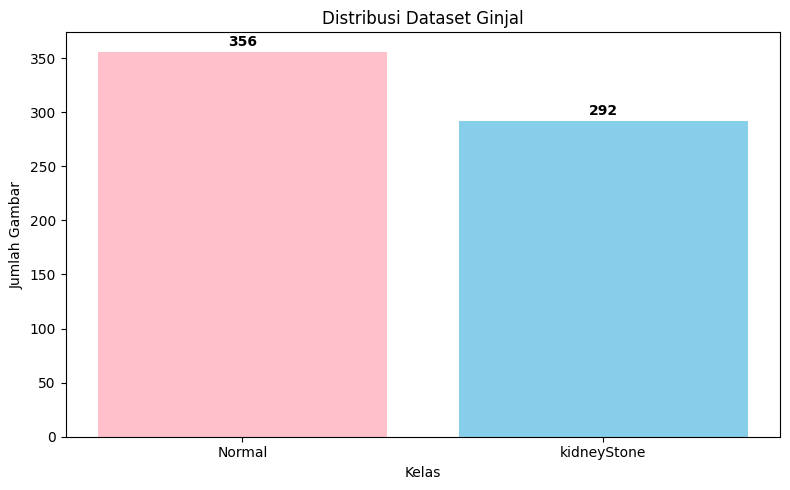

In [3]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['pink', 'skyblue'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Ginjal')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Visualisasi Sampel Citra Dataset

### Fungsi
Cell ini menampilkan beberapa contoh citra dari masing-masing kelas yang terdapat dalam dataset.

### Analisis
Visualisasi sampel citra bertujuan melakukan pemeriksaan awal terhadap kualitas data dan memastikan proses pembacaan citra berjalan dengan baik sebelum dilakukan preprocessing lebih lanjut.

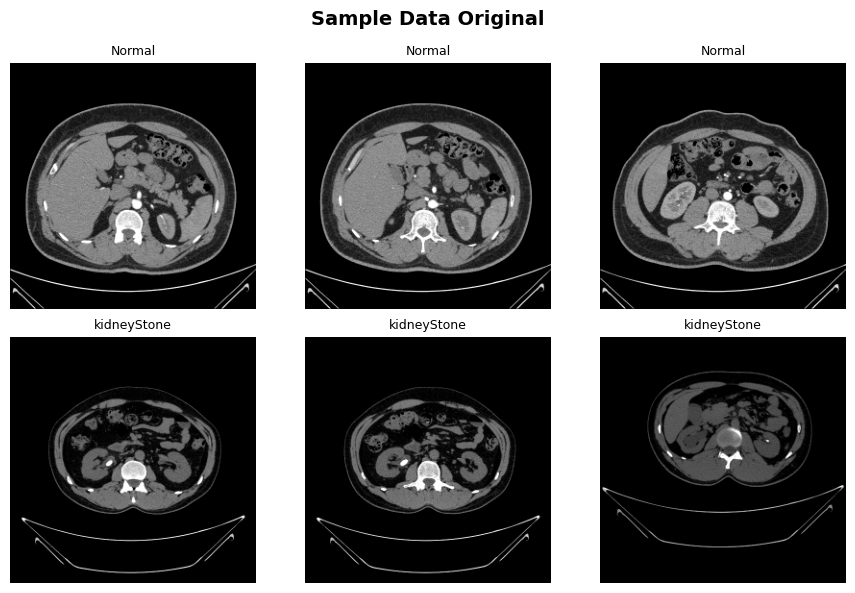

In [4]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Konversi Citra ke Grayscale

### Fungsi
Cell ini mengubah seluruh citra berwarna menjadi citra grayscale menggunakan fungsi konversi warna pada OpenCV.

### Analisis
Metode GLCM bekerja berdasarkan hubungan tingkat keabuan antar piksel sehingga informasi warna tidak diperlukan.

Konversi grayscale membantu mengurangi kompleksitas data dan memfokuskan analisis pada karakteristik tekstur citra.

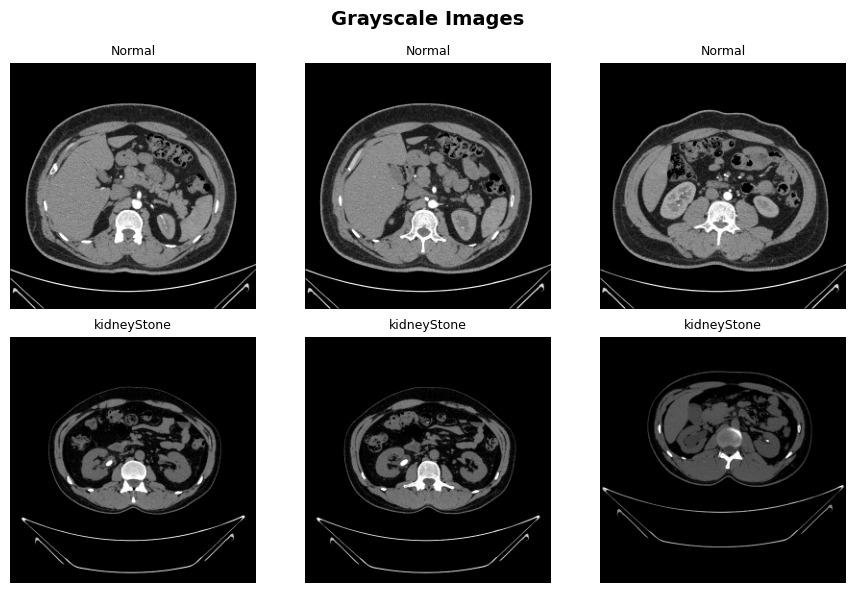

In [5]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Penerapan Median Filter

### Fungsi
Cell ini menerapkan Median Filter pada seluruh citra grayscale untuk mengurangi noise yang terdapat pada citra.

### Analisis
Median Filter bekerja dengan mengganti nilai suatu piksel menggunakan nilai median dari piksel-piksel di sekitarnya.

Keunggulan metode ini adalah mampu mengurangi noise tanpa merusak detail tepi objek sehingga sangat cocok digunakan pada citra medis.

Hasil yang diperoleh berupa citra yang lebih bersih dan siap untuk proses peningkatan kualitas citra berikutnya.

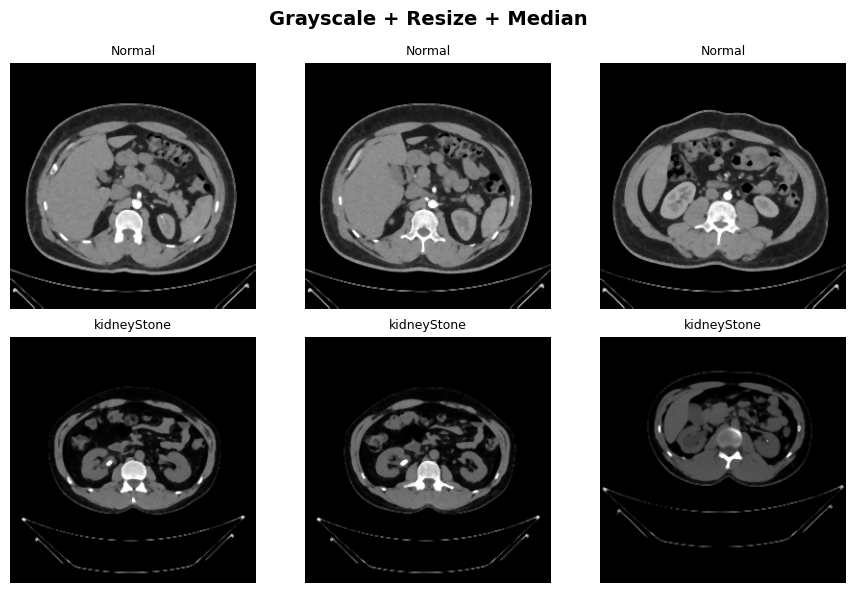

In [6]:
# Fungsi Median Filter
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

# Menerapkan Median Filter
img_median = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    img_median.append(filtered)
img_median = np.array(img_median)

show_sample_images(img_median, labels, class_names, 'Grayscale + Resize + Median')

## Penerapan Contrast Limited Adaptive Histogram Equalization (CLAHE)

### Fungsi
Cell ini menerapkan metode CLAHE pada citra hasil Median Filter untuk meningkatkan kontras citra secara lokal.

### Analisis
CLAHE bekerja dengan membagi citra menjadi beberapa wilayah kecil kemudian meningkatkan kontras pada masing-masing wilayah tersebut.

Keunggulan CLAHE antara lain:

- Meningkatkan kontras lokal.
- Memperjelas detail tekstur.
- Mengurangi efek pencahayaan yang tidak merata.
- Menghindari peningkatan noise berlebihan.

Metode ini sangat sesuai digunakan pada citra medis karena mampu memperjelas detail jaringan tanpa menyebabkan distorsi yang signifikan.

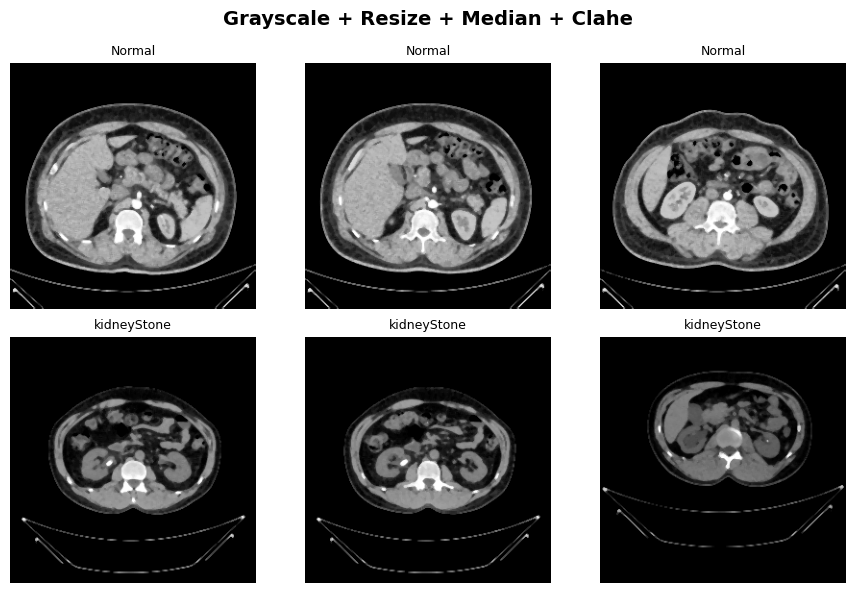

In [7]:
def clahe_manual(img, clip_limit=2.0):
    hist = np.zeros(256)
    for pixel in img.flatten():
        hist[pixel] += 1
    clip_value = clip_limit * img.size / 256
    excess = 0
    for i in range(256):
        if hist[i] > clip_value:
            excess += hist[i] - clip_value
            hist[i] = clip_value
    hist += excess / 256
    cdf = np.cumsum(hist)
    cdf = (cdf - cdf.min()) / (cdf.max() - cdf.min())
    lut = np.round(cdf * 255).astype(np.uint8)
    return lut[img]
img_clahe = []
for img in img_median:
    img_clahe.append(clahe_manual(img))
img_clahe = np.array(img_clahe)
show_sample_images(
    img_clahe,
    labels,
    class_names,
    'Grayscale + Resize + Median + Clahe'
)

## Penerapan Thresholding

### Fungsi
Cell ini menerapkan proses Thresholding pada citra hasil CLAHE.

Thresholding merupakan teknik segmentasi citra yang mengubah citra grayscale menjadi citra biner berdasarkan nilai ambang (threshold) tertentu.

Piksel dengan intensitas di atas nilai threshold akan diberikan nilai putih, sedangkan piksel di bawah threshold akan diberikan nilai hitam.

### Analisis
Tujuan utama penggunaan Thresholding adalah memisahkan area objek dari latar belakang sehingga pola penting pada citra menjadi lebih mudah dikenali.

Manfaat penggunaan Thresholding antara lain:

- Menonjolkan area objek utama.
- Mengurangi informasi yang tidak relevan.
- Mempermudah analisis tekstur.
- Meningkatkan fokus terhadap struktur yang menjadi objek penelitian.

Pada citra ginjal, proses ini membantu memperjelas area yang berpotensi mengandung batu ginjal sehingga karakteristik tekstur dapat diekstraksi dengan lebih baik menggunakan GLCM.

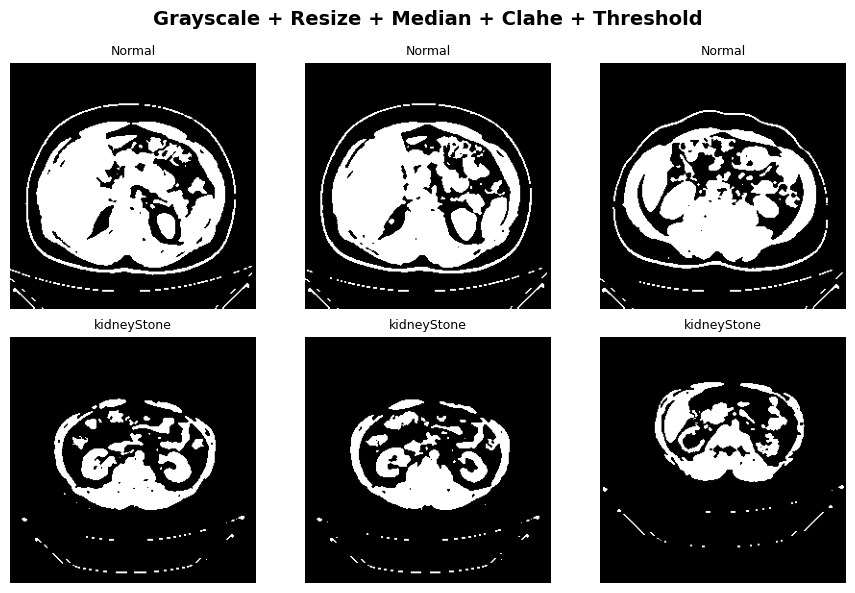

In [8]:
def threshold_edge(img, threshold):
    canvas = np.zeros_like(img)

    canvas[img >= threshold] = 255
    canvas[img < threshold] = 0

    return canvas.astype(np.uint8)
dataPreprocessed = []
for img in img_clahe:
    sharpened = threshold_edge(img, 90)
    dataPreprocessed.append(sharpened)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Grayscale + Resize + Median + Clahe + Threshold')

In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

## Definisi Fungsi GLCM dan Fitur Tekstur

### Fungsi
Cell ini mendefinisikan fungsi pembentukan matriks Gray Level Co-occurrence Matrix (GLCM) dan perhitungan fitur tekstur yang akan digunakan pada proses klasifikasi.

Fitur yang dihitung meliputi:

- Contrast
- Dissimilarity
- Homogeneity
- Energy
- Correlation
- ASM

### Analisis
GLCM merupakan metode statistik orde kedua yang digunakan untuk menggambarkan hubungan spasial antar piksel dalam citra.

Fitur yang dihasilkan mampu merepresentasikan pola tekstur yang terdapat pada citra ginjal.

## Pembentukan Matriks GLCM pada Berbagai Sudut

### Fungsi
Cell ini membentuk matriks GLCM pada empat orientasi sudut:

- 0°
- 45°
- 90°
- 135°

### Analisis
Penggunaan beberapa sudut bertujuan memperoleh informasi tekstur yang lebih lengkap karena pola tekstur dapat berbeda pada setiap arah.

In [10]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 648 images


## Ekstraksi Fitur Tekstur GLCM

### Fungsi
Cell ini melakukan ekstraksi fitur tekstur dari matriks GLCM yang telah dibentuk sebelumnya.

### Analisis
Tahap ekstraksi fitur mengubah informasi visual citra menjadi representasi numerik yang dapat diproses oleh algoritma Machine Learning.

Fitur-fitur yang diperoleh diharapkan mampu membedakan karakteristik tekstur antara ginjal normal dan ginjal batu.

In [11]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


## Pembentukan Dataset Fitur GLCM

### Fungsi
Cell ini menyusun seluruh fitur hasil ekstraksi Gray Level Co-occurrence Matrix (GLCM) ke dalam bentuk DataFrame menggunakan library Pandas.

Setiap baris merepresentasikan satu citra ginjal, sedangkan setiap kolom merepresentasikan fitur tekstur yang diperoleh dari proses ekstraksi GLCM pada berbagai orientasi sudut.

Dataset yang terbentuk terdiri dari:

- Filename
- Label
- Contrast (0°, 45°, 90°, 135°)
- Homogeneity (0°, 45°, 90°, 135°)
- Dissimilarity (0°, 45°, 90°, 135°)
- Entropy (0°, 45°, 90°, 135°)
- ASM (0°, 45°, 90°, 135°)
- Energy (0°, 45°, 90°, 135°)
- Correlation (0°, 45°, 90°, 135°)

### Analisis

Hasil ekstraksi menghasilkan dataset fitur tekstur yang terdiri dari citra kelas Normal dan Kidney Stone yang siap digunakan pada proses klasifikasi.

Pada percobaan ini citra telah melalui tahapan preprocessing berupa:

1. Resize (256×256)
2. Grayscale
3. Median Filter
4. CLAHE
5. Thresholding

Median Filter digunakan untuk mengurangi noise, CLAHE digunakan untuk meningkatkan kontras lokal citra, sedangkan Thresholding digunakan untuk memisahkan area objek dari latar belakang sehingga pola utama pada citra menjadi lebih dominan.

Penggunaan Thresholding menyebabkan sebagian besar piksel yang tidak relevan dapat diminimalkan sehingga karakteristik tekstur objek menjadi lebih jelas. Akibatnya fitur GLCM yang dihasilkan lebih berfokus pada pola tekstur utama yang terdapat pada area ginjal.

Perbedaan nilai fitur yang muncul antara kelas Normal dan Kidney Stone menunjukkan bahwa metode GLCM mampu menangkap perubahan tekstur yang terjadi akibat keberadaan batu ginjal. Informasi tersebut kemudian direpresentasikan dalam bentuk data numerik yang dapat diproses oleh algoritma Machine Learning.

Output dari tahap ini berupa dataset fitur tekstur yang telah terstruktur dan siap digunakan untuk proses seleksi fitur, normalisasi, serta klasifikasi.

In [12]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan4.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan4.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,1.jpg,Normal,2420.507812,3778.0,2836.875000,3682.0,0.962776,0.941900,0.956373,0.943376,...,0.523259,0.510686,0.727408,0.713708,0.723367,0.714623,0.914435,0.866710,0.899711,0.870097
1,10.jpg,Normal,2504.179688,3856.0,2852.812500,3752.0,0.961490,0.940701,0.956128,0.942300,...,0.526618,0.513294,0.729043,0.715459,0.725684,0.716445,0.910744,0.862837,0.898310,0.866536
2,100.jpg,Normal,2356.757813,3800.0,2926.523438,3692.0,0.963757,0.941562,0.954995,0.943223,...,0.567703,0.556169,0.758755,0.744781,0.753461,0.745767,0.906914,0.850263,0.884397,0.854518
3,11.jpg,Normal,2506.171875,3820.0,2858.789062,3812.0,0.961459,0.941254,0.956036,0.941377,...,0.527091,0.513023,0.729398,0.716180,0.726010,0.716256,0.910560,0.863946,0.897965,0.864231
4,12.jpg,Normal,2522.109375,3844.0,2838.867188,3772.0,0.961214,0.940885,0.956343,0.941992,...,0.528251,0.514444,0.729845,0.716566,0.726808,0.717247,0.909807,0.862813,0.898469,0.865382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,Stone- (515).jpg,kidneyStone,2033.027344,3565.0,2918.554688,3551.0,0.968735,0.945176,0.955117,0.945391,...,0.639899,0.630343,0.807803,0.793821,0.799937,0.793942,0.901423,0.827610,0.858515,0.828287
644,Stone- (516).jpg,kidneyStone,2044.980469,3565.0,2926.523438,3573.0,0.968551,0.945176,0.954995,0.945053,...,0.641030,0.631287,0.808465,0.794605,0.800644,0.794536,0.900453,0.826932,0.857571,0.826544
645,Stone- (517).jpg,kidneyStone,2041.992188,3590.0,2982.304688,3602.0,0.968597,0.944791,0.954137,0.944607,...,0.641703,0.632355,0.809396,0.795311,0.801064,0.795208,0.900137,0.824909,0.854185,0.824324
646,Stone- (518).jpg,kidneyStone,2087.812500,3649.0,3037.089844,3669.0,0.967893,0.943884,0.953294,0.943576,...,0.641172,0.631674,0.809126,0.794951,0.800732,0.794779,0.897823,0.821900,0.851397,0.820923


## Seleksi Fitur Menggunakan Correlation Matrix

### Fungsi
Cell ini melakukan proses seleksi fitur menggunakan metode Correlation Matrix untuk mengidentifikasi fitur-fitur yang memiliki korelasi sangat tinggi.

Fitur yang memiliki nilai korelasi melebihi ambang batas yang ditentukan dianggap membawa informasi yang serupa sehingga salah satunya dapat dihapus untuk mengurangi redundansi data.

### Hasil Seleksi Fitur

Berdasarkan proses seleksi diperoleh:

- Jumlah fitur sebelum seleksi : **28 fitur**
- Jumlah fitur setelah seleksi : **10 fitur**
- Jumlah fitur yang dihapus : **18 fitur**

Fitur yang terpilih adalah:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Homogeneity45
- Homogeneity90
- Entropy0
- ASM0
- Correlation0
- Correlation45

### Alasan Penggunaan Correlation Matrix

Pada hasil ekstraksi GLCM, setiap fitur dihitung pada beberapa orientasi sudut sehingga banyak fitur memiliki hubungan yang sangat kuat satu sama lain.

Apabila seluruh fitur digunakan secara bersamaan, maka dapat terjadi:

- Redundansi informasi.
- Kompleksitas model yang lebih tinggi.
- Waktu pelatihan yang lebih lama.
- Risiko overfitting yang meningkat.

Oleh karena itu dilakukan seleksi fitur untuk mempertahankan fitur yang paling representatif dan menghilangkan fitur yang memiliki informasi yang berulang.

### Analisis Hasil

Hasil seleksi menunjukkan bahwa dari 28 fitur awal hanya 10 fitur yang dipertahankan. Hal ini menunjukkan bahwa sebagian fitur GLCM memiliki korelasi yang sangat tinggi sehingga tidak memberikan informasi tambahan yang signifikan.

Berbeda dengan preprocessing sebelumnya yang didominasi oleh fitur Contrast dan Correlation, pada preprocessing ini fitur Homogeneity, Entropy, dan ASM juga tetap bertahan setelah proses seleksi.

Hal ini menunjukkan bahwa proses Thresholding memberikan pengaruh terhadap karakteristik tekstur citra. Dengan mengubah citra menjadi area-area yang lebih tegas antara objek dan latar belakang, tingkat keseragaman pola tekstur menjadi lebih mudah diamati sehingga fitur Homogeneity menjadi lebih relevan.

Selain itu, fitur Entropy yang menggambarkan tingkat kompleksitas tekstur juga tetap dipertahankan. Hal ini menunjukkan bahwa perbedaan kompleksitas pola antara ginjal normal dan ginjal batu masih mengandung informasi penting untuk proses klasifikasi.

Fitur ASM yang mengukur tingkat keteraturan distribusi piksel juga bertahan setelah seleksi. Kondisi ini mengindikasikan bahwa setelah proses Thresholding, pola distribusi tekstur menjadi salah satu faktor yang berperan dalam membedakan kedua kelas citra.

Secara keseluruhan, fitur yang terpilih menunjukkan bahwa proses klasifikasi pada preprocessing ini dipengaruhi oleh beberapa aspek tekstur sekaligus, yaitu:

- Variasi intensitas piksel (Contrast)
- Keseragaman tekstur (Homogeneity)
- Kompleksitas pola tekstur (Entropy)
- Keteraturan distribusi piksel (ASM)
- Hubungan spasial antar piksel (Correlation)

Keberagaman fitur yang dipertahankan menunjukkan bahwa kombinasi Median Filter, CLAHE, dan Thresholding mampu menghasilkan representasi tekstur yang lebih kaya dibandingkan hanya mengandalkan satu jenis karakteristik tekstur saja.

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 10
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Entropy0', 'ASM0', 'Correlation0', 'Correlation45']


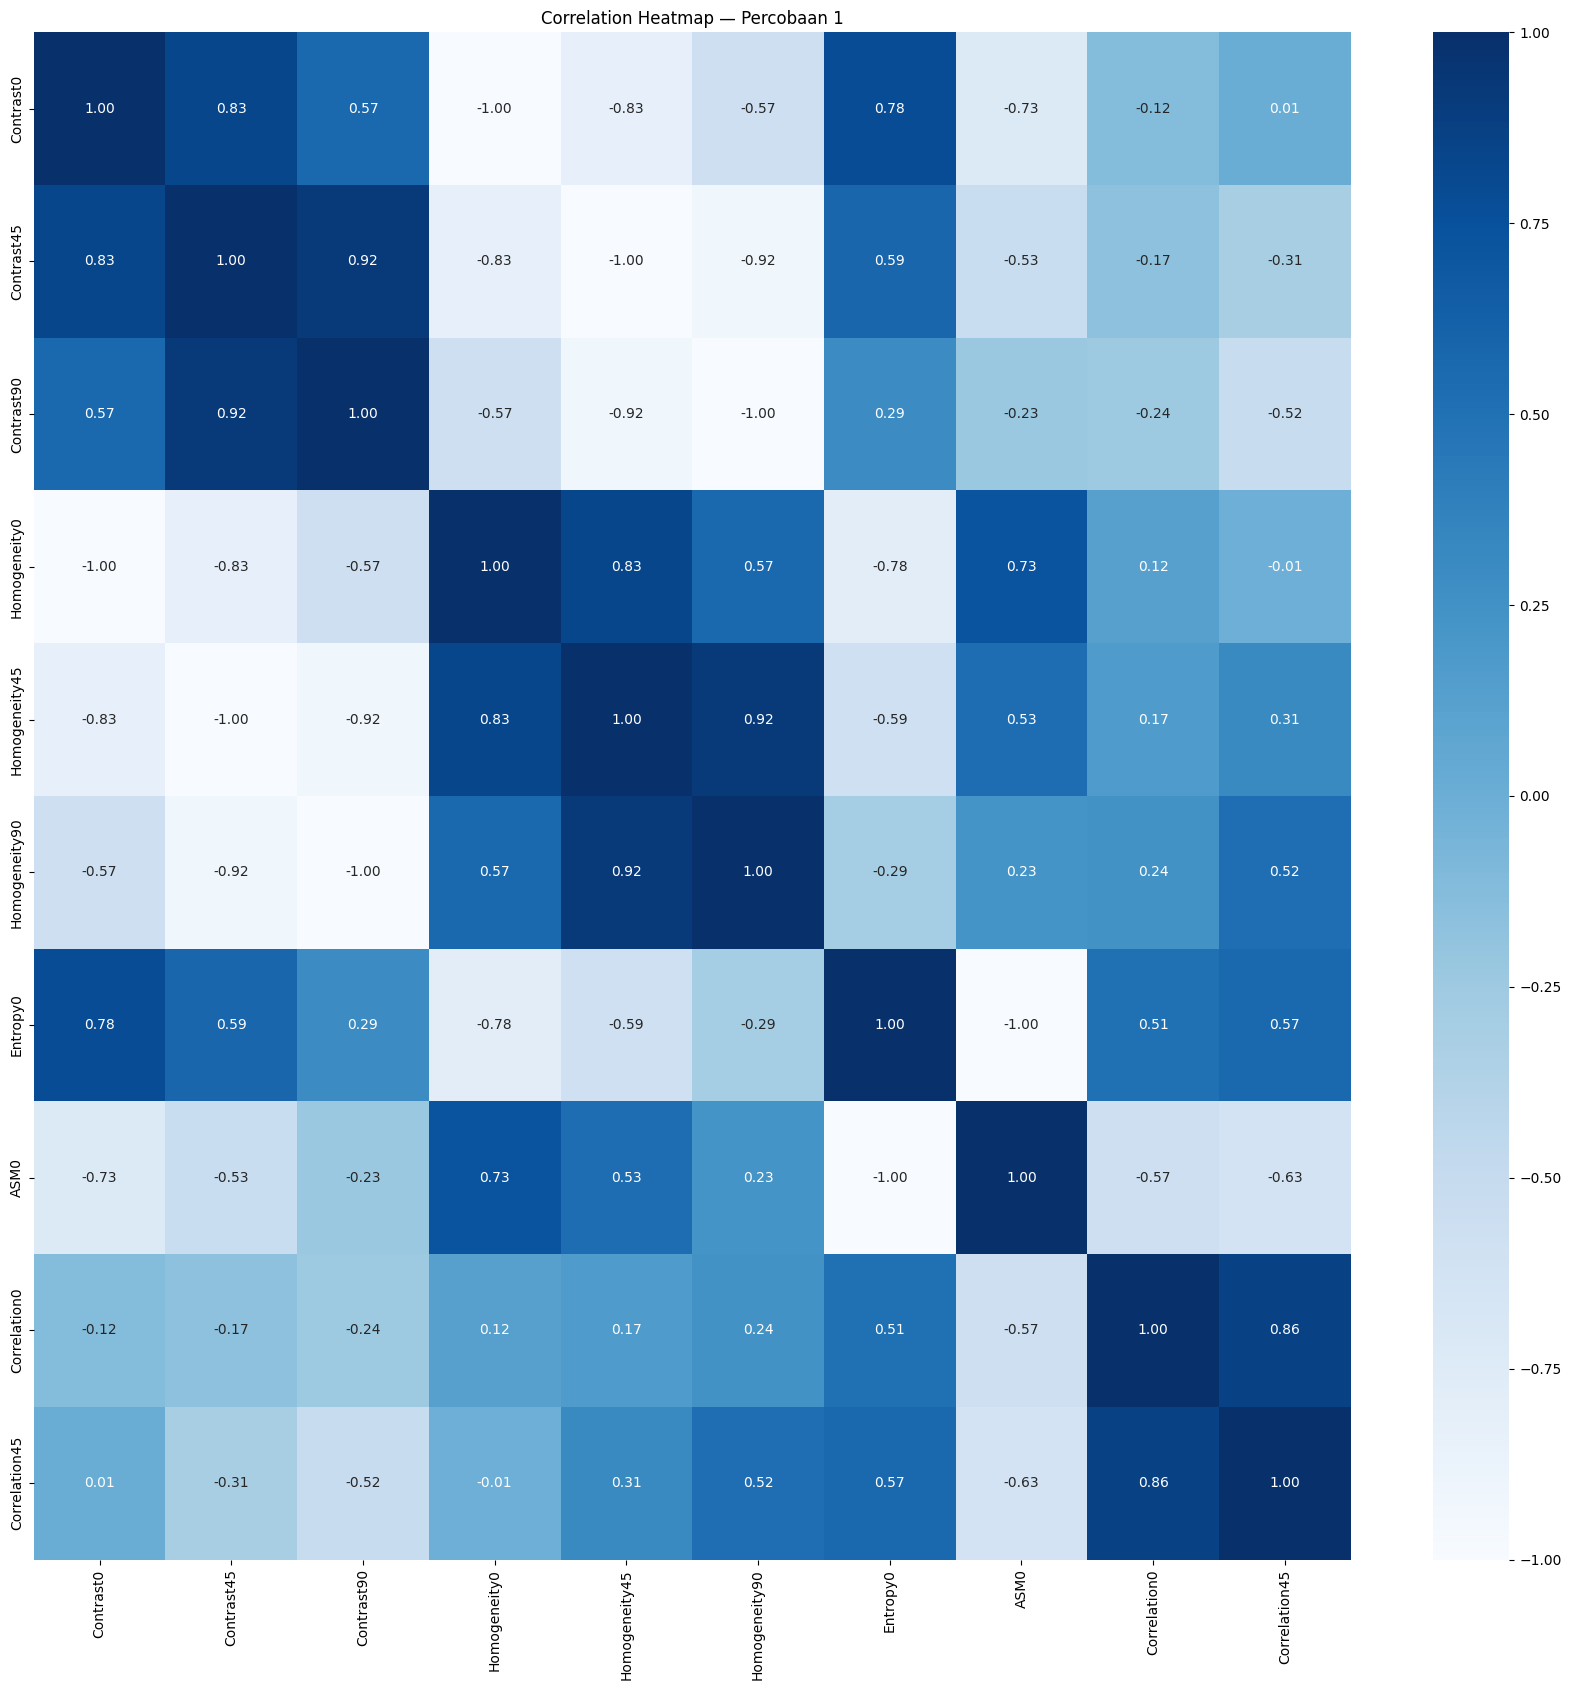

In [13]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

## Pembagian Data Training dan Testing

### Fungsi
Cell ini membagi dataset fitur hasil seleksi menjadi data training dan data testing menggunakan fungsi `train_test_split()` dari library Scikit-Learn.

Pembagian data dilakukan secara acak untuk memastikan bahwa data training dan data testing memiliki distribusi yang representatif terhadap keseluruhan dataset.

### Hasil Pembagian Data

Berdasarkan proses pembagian data diperoleh:

- Data Training : **518 data**
- Data Testing : **130 data**
- Total Data : **648 data**

Setelah proses seleksi fitur, jumlah fitur yang digunakan pada tahap klasifikasi adalah sebanyak **10 fitur**, yaitu:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Homogeneity45
- Homogeneity90
- Entropy0
- ASM0
- Correlation0
- Correlation45

Sehingga ukuran dataset yang dihasilkan adalah:

- Training set : **(518, 10)**
- Testing set : **(130, 10)**

Proporsi pembagian data yang digunakan adalah sekitar:

- **80% data training**
- **20% data testing**

### Analisis

Data training digunakan untuk melatih model klasifikasi agar dapat mempelajari hubungan antara fitur tekstur GLCM dan kelas citra ginjal. Sementara itu, data testing digunakan untuk mengevaluasi kemampuan model dalam melakukan prediksi terhadap data yang tidak digunakan selama proses pelatihan.

Pada preprocessing keempat, citra telah melalui tahapan Median Filter, CLAHE, dan Thresholding sebelum proses ekstraksi fitur dilakukan. Kombinasi preprocessing tersebut menghasilkan representasi tekstur yang lebih terfokus pada area objek utama sehingga informasi tekstur yang diperoleh menjadi lebih jelas dan terstruktur.

Hasil seleksi fitur menunjukkan bahwa sebanyak 10 fitur dipertahankan dari total 28 fitur awal. Fitur-fitur yang bertahan mencakup Contrast, Homogeneity, Entropy, ASM, dan Correlation yang masing-masing merepresentasikan variasi intensitas piksel, tingkat keseragaman tekstur, kompleksitas pola, keteraturan distribusi piksel, serta hubungan spasial antar piksel.

Berbeda dengan preprocessing ketiga yang hanya mempertahankan 6 fitur, pada preprocessing keempat jumlah fitur yang bertahan lebih banyak. Hal ini menunjukkan bahwa proses Thresholding mampu mempertahankan variasi karakteristik tekstur yang lebih beragam sehingga lebih banyak fitur yang dianggap relevan setelah proses seleksi.

Sebanyak 518 data digunakan untuk proses pelatihan model dan 130 data digunakan untuk proses pengujian. Proporsi 80:20 dipilih karena memberikan jumlah data yang cukup besar untuk proses pembelajaran model sekaligus menyediakan data yang memadai untuk mengevaluasi kemampuan generalisasi model terhadap data yang belum pernah dilihat sebelumnya.

Pembagian data dilakukan menggunakan parameter `random_state` yang tetap sehingga hasil eksperimen dapat direproduksi kembali pada penelitian selanjutnya. Selain itu, seluruh algoritma klasifikasi menggunakan data training dan testing yang sama sehingga perbandingan performa antar model dapat dilakukan secara lebih objektif.

Tahap ini sangat penting karena memungkinkan evaluasi performa model dilakukan secara adil dan memberikan gambaran mengenai kemampuan model dalam mengenali pola tekstur ginjal normal dan ginjal yang mengandung batu pada data baru.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (518, 10)
Testing set: (130, 10)


In [15]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Normalisasi Data Fitur

### Fungsi
Cell ini melakukan normalisasi data menggunakan metode **Z-Score Standardization** atau **Standard Scaling**.

Normalisasi dilakukan dengan rumus:

\[
Z = \frac{x-\mu}{\sigma}
\]

dengan:

- \(x\) = nilai fitur
- \(\mu\) = rata-rata fitur pada data training
- \(\sigma\) = standar deviasi fitur pada data training

Pada proses ini, nilai rata-rata dan standar deviasi dihitung dari data training, kemudian digunakan untuk menormalisasi data training maupun data testing.

### Alasan Dilakukan Normalisasi

Fitur-fitur hasil ekstraksi GLCM memiliki rentang nilai yang berbeda-beda.

Sebagai contoh:

- Contrast dapat memiliki nilai hingga ribuan.
- Correlation umumnya berada pada rentang 0 hingga 1.
- Homogeneity biasanya memiliki nilai sekitar 0,4 hingga 0,8.

Perbedaan skala tersebut dapat menyebabkan fitur dengan nilai yang lebih besar mendominasi proses pembelajaran model.

Oleh karena itu dilakukan normalisasi agar seluruh fitur berada pada skala yang sebanding.

### Analisis

Setelah proses normalisasi, setiap fitur memiliki:

- Rata-rata (mean) mendekati 0.
- Standar deviasi (standard deviation) mendekati 1.

Proses ini membuat seluruh fitur memiliki kontribusi yang lebih seimbang selama proses klasifikasi.

Normalisasi menjadi sangat penting terutama pada algoritma:

- Support Vector Machine (SVM)
- K-Nearest Neighbor (KNN)

karena kedua algoritma tersebut menggunakan perhitungan jarak atau posisi data dalam ruang fitur. Apabila terdapat fitur dengan rentang nilai yang jauh lebih besar dibandingkan fitur lainnya, maka fitur tersebut dapat mendominasi proses klasifikasi dan menyebabkan hasil prediksi menjadi kurang optimal.

Pada penelitian ini, nilai rata-rata dan standar deviasi dihitung dari data training kemudian digunakan untuk menormalisasi data training dan data testing. Pendekatan ini dilakukan untuk menghindari terjadinya *data leakage*, yaitu kondisi ketika informasi dari data testing ikut digunakan selama proses pelatihan model.

Dengan demikian, proses evaluasi model dapat dilakukan secara lebih objektif dan mencerminkan kemampuan model dalam menghadapi data baru yang belum pernah dilihat sebelumnya.

In [16]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

## Inisialisasi Model Klasifikasi dan Fungsi Evaluasi

### Fungsi

Cell ini mendefinisikan fungsi evaluasi serta menginisialisasi tiga algoritma klasifikasi yang akan digunakan dalam penelitian, yaitu:

1. Random Forest (RF)
2. Support Vector Machine (SVM)
3. K-Nearest Neighbor (KNN)

Selain itu, dibuat fungsi `generateClassificationReport()` untuk menampilkan hasil evaluasi model berupa:

- Precision
- Recall
- F1-Score
- Accuracy

Hasil evaluasi tersebut digunakan untuk membandingkan performa masing-masing algoritma dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

### Alasan Pemilihan Algoritma

Ketiga algoritma dipilih karena memiliki pendekatan klasifikasi yang berbeda sehingga dapat memberikan perbandingan performa yang lebih komprehensif terhadap fitur tekstur GLCM yang digunakan.

- Random Forest mewakili metode berbasis ensemble learning.
- SVM mewakili metode berbasis hyperplane.
- KNN mewakili metode berbasis kedekatan jarak antar data.

Dengan menggunakan ketiga algoritma tersebut, dapat diketahui algoritma mana yang paling efektif dalam mengenali pola tekstur citra ginjal.

### Parameter Model

#### Random Forest

```python
RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
```

Parameter `n_estimators=100` menunjukkan bahwa model membangun 100 pohon keputusan (*decision tree*) yang kemudian digabungkan melalui mekanisme voting untuk menghasilkan keputusan akhir.

Jumlah 100 pohon dipilih karena secara umum mampu memberikan keseimbangan antara akurasi dan waktu komputasi. Jumlah pohon yang terlalu sedikit dapat menyebabkan model kurang stabil, sedangkan jumlah yang terlalu banyak dapat meningkatkan waktu pelatihan tanpa peningkatan performa yang signifikan.

Parameter `random_state=42` digunakan untuk memastikan proses pembentukan model dapat direproduksi kembali pada percobaan berikutnya. Dengan nilai random state yang tetap, hasil eksperimen akan tetap konsisten setiap kali kode dijalankan.

#### Support Vector Machine (SVM)

```python
SVC(
    kernel='rbf',
    random_state=42
)
```

Kernel `rbf` (*Radial Basis Function*) dipilih karena mampu menangani hubungan non-linear antar fitur. Pada data tekstur GLCM, batas pemisah antara kelas Normal dan Kidney Stone belum tentu berbentuk linear sehingga kernel RBF sering memberikan performa yang lebih baik dibandingkan kernel linear.

Parameter `random_state=42` digunakan untuk menjaga konsistensi hasil eksperimen.

#### K-Nearest Neighbor (KNN)

```python
KNeighborsClassifier(
    n_neighbors=5
)
```

Parameter `n_neighbors=5` menunjukkan bahwa proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari suatu data.

Nilai K = 5 dipilih karena merupakan nilai yang umum digunakan dan mampu memberikan keseimbangan antara sensitivitas terhadap noise dan kemampuan generalisasi model. Nilai K yang terlalu kecil dapat menyebabkan model terlalu sensitif terhadap data tertentu, sedangkan nilai K yang terlalu besar dapat menyebabkan batas antar kelas menjadi kurang jelas.

### Analisis

Tahap ini merupakan langkah awal sebelum proses pelatihan model dilakukan. Parameter yang digunakan pada masing-masing algoritma dipilih berdasarkan konfigurasi yang umum digunakan dalam penelitian klasifikasi serta mampu memberikan performa yang stabil tanpa memerlukan proses optimasi parameter yang kompleks.

Dengan menggunakan konfigurasi yang sama pada seluruh percobaan preprocessing, perbedaan performa yang diperoleh nantinya lebih mencerminkan pengaruh teknik preprocessing dan kualitas fitur yang dihasilkan dibandingkan pengaruh perubahan parameter model.

Oleh karena itu, hasil evaluasi yang diperoleh dapat digunakan sebagai dasar yang lebih objektif untuk membandingkan performa Random Forest, Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) dalam mengklasifikasikan citra ginjal normal dan citra batu ginjal.

## Pelatihan dan Pengujian Model Random Forest

### Fungsi

Cell ini digunakan untuk melatih model Random Forest menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Tujuan evaluasi ini adalah untuk mengukur kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur yang telah diekstraksi.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **518 data**, terdiri dari:

- 278 citra Normal
- 240 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data testing yang digunakan sebanyak **130 data**, terdiri dari:

- 78 citra Normal
- 52 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Random Forest berhasil mengklasifikasikan seluruh data training maupun data testing dengan benar sehingga memperoleh nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Tidak ditemukan kesalahan klasifikasi pada kedua kelas, baik Normal maupun Kidney Stone. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM memiliki kemampuan yang sangat baik dalam merepresentasikan karakteristik masing-masing kelas.

Pada preprocessing keempat, citra telah melalui beberapa tahapan peningkatan kualitas citra yaitu Median Filter, CLAHE, dan Thresholding sebelum proses ekstraksi fitur dilakukan. Median Filter digunakan untuk mengurangi noise, CLAHE digunakan untuk meningkatkan kontras lokal citra, sedangkan Thresholding digunakan untuk memisahkan area objek dari latar belakang sehingga pola tekstur utama menjadi lebih dominan.

Setelah proses seleksi fitur, diperoleh 10 fitur yang dipertahankan dari total 28 fitur awal, yaitu:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Homogeneity45
- Homogeneity90
- Entropy0
- ASM0
- Correlation0
- Correlation45

Fitur-fitur tersebut menunjukkan bahwa proses klasifikasi pada preprocessing ini dipengaruhi oleh beberapa karakteristik tekstur sekaligus, yaitu variasi intensitas piksel (Contrast), tingkat keseragaman tekstur (Homogeneity), kompleksitas pola tekstur (Entropy), keteraturan distribusi piksel (ASM), serta hubungan spasial antar piksel (Correlation).

Berbeda dengan preprocessing ketiga yang hanya mempertahankan 6 fitur, preprocessing keempat masih mempertahankan 10 fitur setelah proses seleksi. Hal ini menunjukkan bahwa proses Thresholding mampu mempertahankan lebih banyak informasi tekstur yang relevan sehingga karakteristik citra dapat direpresentasikan oleh lebih banyak aspek tekstur.

Keberhasilan model mencapai akurasi 100% menunjukkan bahwa kombinasi Median Filter, CLAHE, dan Thresholding mampu menghasilkan representasi tekstur yang sangat baik untuk membedakan citra ginjal normal dan citra batu ginjal.

Selain itu, kesamaan performa antara data training dan data testing menunjukkan bahwa model mampu mempertahankan performanya ketika dihadapkan pada data yang belum pernah dilihat sebelumnya. Berdasarkan hasil evaluasi yang diperoleh, tidak ditemukan indikasi penurunan performa yang mengarah pada overfitting.

Hasil Random Forest pada preprocessing keempat selanjutnya akan dibandingkan dengan preprocessing lainnya untuk mengetahui pengaruh kombinasi Median Filter, CLAHE, dan Thresholding terhadap performa klasifikasi citra ginjal menggunakan fitur tekstur GLCM.

In [17]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       278
 kidneyStone       1.00      1.00      1.00       240

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        78
 kidneyStone       1.00      1.00      1.00        52

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130

Accuracy: 1.0


## Pelatihan dan Pengujian Model Support Vector Machine (SVM)

### Fungsi

Cell ini digunakan untuk melatih model Support Vector Machine (SVM) menggunakan data training yang telah melalui proses preprocessing, ekstraksi fitur GLCM, seleksi fitur, dan normalisasi.

Setelah model selesai dilatih, dilakukan proses prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

Evaluasi dilakukan untuk mengukur kemampuan model dalam membedakan citra ginjal Normal dan Kidney Stone berdasarkan fitur tekstur hasil ekstraksi GLCM.

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 99,23% |
| Precision | 99% - 100% |
| Recall | 98% - 100% |
| F1-Score | 99% |

Jumlah data training yang digunakan sebanyak **518 data**, terdiri dari:

- 278 citra Normal
- 240 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 99,23% |
| Precision | 99% - 100% |
| Recall | 98% - 100% |
| F1-Score | 99% |

Jumlah data testing yang digunakan sebanyak **130 data**, terdiri dari:

- 78 citra Normal
- 52 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model Support Vector Machine (SVM) memiliki performa yang sangat baik dalam mengklasifikasikan citra ginjal Normal dan Kidney Stone dengan nilai Accuracy sebesar **99,23%** baik pada data training maupun data testing.

Nilai Precision, Recall, dan F1-Score yang mendekati 100% menunjukkan bahwa model mampu mengenali kedua kelas dengan tingkat ketepatan yang sangat tinggi. Namun demikian, masih terdapat sejumlah kecil data yang mengalami kesalahan klasifikasi, terutama pada kelas Kidney Stone yang memiliki nilai Recall sebesar 98%.

Nilai Recall Kidney Stone sebesar 98% menunjukkan bahwa sebagian kecil citra batu ginjal masih terklasifikasi sebagai kelas Normal. Meskipun jumlahnya sangat sedikit, kondisi ini menyebabkan nilai akurasi tidak mencapai 100%.

Pada preprocessing keempat, citra telah melalui tahapan Median Filter, CLAHE, dan Thresholding sebelum dilakukan ekstraksi fitur. Median Filter digunakan untuk mengurangi noise, CLAHE digunakan untuk meningkatkan kontras lokal citra, sedangkan Thresholding digunakan untuk memisahkan area objek dari latar belakang sehingga struktur utama pada citra menjadi lebih dominan.

Setelah proses seleksi fitur, diperoleh 10 fitur yang dipertahankan dari total 28 fitur awal, yaitu:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Homogeneity45
- Homogeneity90
- Entropy0
- ASM0
- Correlation0
- Correlation45

Fitur-fitur tersebut menunjukkan bahwa proses klasifikasi tidak hanya dipengaruhi oleh variasi intensitas piksel, tetapi juga oleh tingkat keseragaman tekstur, kompleksitas pola, keteraturan distribusi piksel, dan hubungan spasial antar piksel.

Menariknya, nilai Accuracy pada data training dan data testing hampir identik, yaitu sekitar 99,23%. Kondisi ini menunjukkan bahwa model memiliki tingkat konsistensi yang sangat baik dan mampu mempertahankan performanya ketika dihadapkan pada data yang belum pernah digunakan selama proses pelatihan.

Kesamaan performa antara data training dan data testing juga menunjukkan bahwa model tidak mengalami overfitting yang signifikan. Model mampu mempelajari pola tekstur yang terdapat pada data training dan menerapkannya dengan baik pada data testing tanpa mengalami penurunan performa yang berarti.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi Median Filter, CLAHE, Thresholding, ekstraksi fitur GLCM, dan algoritma SVM mampu menghasilkan model klasifikasi yang sangat akurat dalam membedakan citra ginjal normal dan citra batu ginjal. Meskipun akurasi yang diperoleh sedikit lebih rendah dibandingkan preprocessing lainnya yang mencapai 100%, performa yang dihasilkan tetap sangat tinggi dan menunjukkan kemampuan generalisasi yang baik terhadap data baru.

In [18]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99       278
 kidneyStone       1.00      0.98      0.99       240

    accuracy                           0.99       518
   macro avg       0.99      0.99      0.99       518
weighted avg       0.99      0.99      0.99       518

Accuracy: 0.9922779922779923

------Testing Set------
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99        78
 kidneyStone       1.00      0.98      0.99        52

    accuracy                           0.99       130
   macro avg       0.99      0.99      0.99       130
weighted avg       0.99      0.99      0.99       130

Accuracy: 0.9923076923076923


## Pelatihan dan Pengujian Model K-Nearest Neighbor (KNN)

### Fungsi

Cell ini digunakan untuk melatih dan menguji model K-Nearest Neighbor (KNN) menggunakan data hasil ekstraksi fitur GLCM yang telah melalui proses seleksi fitur dan normalisasi.

Pada penelitian ini digunakan parameter:

```python
KNeighborsClassifier(n_neighbors=5)
```

yang berarti proses klasifikasi dilakukan berdasarkan lima tetangga terdekat dari setiap data yang akan diprediksi.

Setelah model selesai dibangun, dilakukan prediksi terhadap data training dan data testing. Hasil prediksi kemudian dievaluasi menggunakan metrik:

- Precision
- Recall
- F1-Score
- Accuracy

### Hasil Pengujian

#### Data Training

Berdasarkan hasil evaluasi pada data training diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 100% |
| Precision | 100% |
| Recall | 100% |
| F1-Score | 100% |

Jumlah data training yang digunakan sebanyak **518 data**, terdiri dari:

- 278 citra Normal
- 240 citra Kidney Stone

#### Data Testing

Berdasarkan hasil evaluasi pada data testing diperoleh:

| Metrik | Nilai |
|---------|---------|
| Accuracy | 99,23% |
| Precision | 99% - 100% |
| Recall | 98% - 100% |
| F1-Score | 99% |

Jumlah data testing yang digunakan sebanyak **130 data**, terdiri dari:

- 78 citra Normal
- 52 citra Kidney Stone

### Analisis

Hasil pengujian menunjukkan bahwa model K-Nearest Neighbor (KNN) memiliki performa yang sangat baik dalam mengklasifikasikan citra ginjal Normal dan Kidney Stone.

Pada data training, model berhasil mencapai Accuracy sebesar **100%**, yang menunjukkan bahwa seluruh data pelatihan dapat diklasifikasikan dengan benar. Namun pada data testing diperoleh Accuracy sebesar **99,23%**, sehingga terdapat sejumlah kecil data yang mengalami kesalahan klasifikasi.

Penurunan performa tersebut terlihat pada kelas Kidney Stone yang memiliki nilai Recall sebesar **98%**. Hal ini menunjukkan bahwa masih terdapat sebagian kecil citra batu ginjal yang terprediksi sebagai kelas Normal. Meskipun jumlahnya sangat sedikit, kondisi ini menyebabkan nilai Accuracy dan F1-Score tidak mencapai 100%.

Pada preprocessing keempat, citra telah melalui tahapan Median Filter, CLAHE, dan Thresholding sebelum dilakukan ekstraksi fitur. Median Filter digunakan untuk mengurangi noise, CLAHE digunakan untuk meningkatkan kontras lokal citra, sedangkan Thresholding digunakan untuk memisahkan area objek dari latar belakang sehingga struktur utama pada citra menjadi lebih dominan.

Setelah proses seleksi fitur dilakukan, diperoleh 10 fitur yang dipertahankan dari total 28 fitur awal, yaitu:

- Contrast0
- Contrast45
- Contrast90
- Homogeneity0
- Homogeneity45
- Homogeneity90
- Entropy0
- ASM0
- Correlation0
- Correlation45

Fitur-fitur tersebut menunjukkan bahwa proses klasifikasi dipengaruhi oleh berbagai karakteristik tekstur, mulai dari variasi intensitas piksel, tingkat keseragaman tekstur, kompleksitas pola, keteraturan distribusi piksel, hingga hubungan spasial antar piksel.

Karena KNN merupakan algoritma berbasis jarak, normalisasi fitur memiliki peran yang sangat penting dalam menjaga keseimbangan kontribusi setiap fitur. Dengan seluruh fitur berada pada skala yang sebanding, proses pencarian lima tetangga terdekat dapat dilakukan secara lebih akurat.

Meskipun akurasi pada data testing sedikit lebih rendah dibandingkan data training, selisih performa yang terjadi sangat kecil, yaitu sekitar **0,77%**. Kondisi ini menunjukkan bahwa model masih memiliki kemampuan generalisasi yang sangat baik dan tidak mengalami penurunan performa yang signifikan ketika dihadapkan pada data baru.

Salah satu kemungkinan penyebab penurunan performa adalah proses Thresholding yang mengubah citra menjadi representasi yang lebih sederhana dengan menghilangkan sebagian informasi intensitas asli. Meskipun langkah ini membantu memperjelas area objek, beberapa informasi tekstur halus yang dapat membantu proses klasifikasi juga berpotensi ikut hilang.

Secara keseluruhan, hasil ini menunjukkan bahwa kombinasi Median Filter, CLAHE, Thresholding, ekstraksi fitur GLCM, seleksi fitur, normalisasi, dan algoritma KNN mampu menghasilkan model klasifikasi yang sangat akurat dalam membedakan citra ginjal normal dan citra batu ginjal. Dengan nilai Accuracy sebesar 99,23%, performa yang dihasilkan masih termasuk sangat tinggi dan menunjukkan bahwa fitur tekstur yang digunakan memiliki kemampuan diskriminasi yang baik terhadap kedua kelas citra.

In [19]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       278
 kidneyStone       1.00      1.00      1.00       240

    accuracy                           1.00       518
   macro avg       1.00      1.00      1.00       518
weighted avg       1.00      1.00      1.00       518

Accuracy: 1.0

------Testing Set------
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99        78
 kidneyStone       1.00      0.98      0.99        52

    accuracy                           0.99       130
   macro avg       0.99      0.99      0.99       130
weighted avg       0.99      0.99      0.99       130

Accuracy: 0.9923076923076923


# Perbandingan Kinerja Ketiga Model Klasifikasi

### Fungsi

Bagian ini digunakan untuk membandingkan performa tiga algoritma klasifikasi, yaitu Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) pada preprocessing keempat.

Perbandingan dilakukan berdasarkan hasil evaluasi pada data testing menggunakan metrik Accuracy, Precision, Recall, dan F1-Score.

### Hasil Perbandingan

| Algoritma | Accuracy | Precision | Recall | F1-Score |
|------------|------------|------------|------------|------------|
| Random Forest | 100% | 100% | 100% | 100% |
| SVM | 99,23% | 99% | 99% | 99% |
| KNN | 99,23% | 99% | 99% | 99% |

### Analisis

Berdasarkan hasil pengujian, Random Forest memperoleh performa terbaik dengan nilai Accuracy, Precision, Recall, dan F1-Score sebesar 100%.

Sementara itu, SVM dan KNN memperoleh nilai Accuracy sebesar 99,23%, yang menunjukkan adanya sejumlah kecil kesalahan klasifikasi pada data testing.

Pada preprocessing keempat, citra telah melalui tahapan Median Filter, CLAHE, dan Thresholding sebelum dilakukan ekstraksi fitur. Thresholding digunakan untuk memisahkan area objek dari latar belakang sehingga struktur utama citra menjadi lebih dominan.

Meskipun proses Thresholding mampu memperjelas area objek, proses tersebut juga berpotensi menghilangkan sebagian informasi intensitas asli yang terdapat pada citra. Hilangnya informasi tersebut dapat mempengaruhi proses klasifikasi terutama pada algoritma yang sangat bergantung pada distribusi fitur dan perhitungan jarak, seperti SVM dan KNN.

Random Forest mampu mempertahankan akurasi 100% karena karakteristik ensemble learning yang dimilikinya membuat model lebih robust terhadap perubahan distribusi fitur. Sebaliknya, SVM dan KNN mengalami sedikit penurunan performa karena sebagian informasi tekstur yang digunakan dalam proses pemisahan kelas menjadi berkurang setelah proses Thresholding.

Secara keseluruhan, preprocessing keempat tetap menghasilkan performa klasifikasi yang sangat tinggi. Namun dibandingkan preprocessing lainnya, hanya Random Forest yang mampu mempertahankan akurasi sempurna sehingga dapat dianggap sebagai algoritma yang paling stabil pada skenario preprocessing ini.

## Visualisasi Confusion Matrix

### Fungsi

Cell ini menampilkan Confusion Matrix untuk mengevaluasi hasil klasifikasi Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) secara lebih rinci.

Confusion Matrix digunakan untuk mengetahui jumlah prediksi yang benar maupun salah pada setiap kelas sehingga dapat memberikan gambaran yang lebih lengkap mengenai performa model dibandingkan hanya menggunakan nilai akurasi.

### Analisis

Berdasarkan hasil Confusion Matrix, sebagian besar data testing berhasil diklasifikasikan dengan benar oleh seluruh algoritma yang digunakan.

Hasil Confusion Matrix menunjukkan:

| Algoritma | TN | FP | FN | TP |
|------------|----|----|----|----|
| Random Forest | 78 | 0 | 0 | 52 |
| SVM | 78 | 0 | 1 | 51 |
| KNN | 78 | 0 | 1 | 51 |

Pada Random Forest, seluruh citra Normal dan Kidney Stone berhasil diklasifikasikan dengan benar sehingga diperoleh nilai False Positive dan False Negative sebesar 0. Kondisi ini menunjukkan bahwa model mampu mempelajari pola tekstur kedua kelas dengan sangat baik sehingga tidak terjadi kesalahan klasifikasi pada data testing.

Keberhasilan Random Forest mencapai hasil sempurna dapat disebabkan oleh karakteristik algoritma yang menggunakan banyak pohon keputusan (*decision tree*) dan mekanisme voting. Pendekatan ini membuat model lebih tahan terhadap variasi data dan lebih mampu menangkap pola kompleks yang terdapat pada fitur tekstur GLCM.

Berbeda dengan Random Forest, algoritma SVM dan KNN masing-masing menghasilkan 1 data False Negative. Hal ini menunjukkan bahwa terdapat satu citra Kidney Stone yang diprediksi sebagai kelas Normal.

Kesalahan tersebut kemungkinan terjadi karena karakteristik tekstur pada citra tersebut memiliki kemiripan dengan tekstur ginjal normal sehingga posisi data berada sangat dekat dengan batas keputusan (*decision boundary*) yang dibentuk oleh model.

Selain itu, pada preprocessing keempat digunakan proses Thresholding yang mengubah citra menjadi representasi yang lebih sederhana dengan memisahkan area objek dan latar belakang. Meskipun proses ini mampu memperjelas area utama ginjal, sebagian informasi intensitas dan tekstur halus pada citra juga berpotensi hilang.

Hilangnya sebagian informasi tekstur tersebut dapat menyebabkan beberapa sampel memiliki karakteristik yang semakin mirip antar kelas. Kondisi ini lebih berpengaruh pada SVM dan KNN karena kedua algoritma sangat bergantung pada posisi data dalam ruang fitur dan hubungan jarak antar sampel.

Tidak terdapat nilai False Positive pada seluruh algoritma, yang berarti tidak ada citra Normal yang salah diprediksi sebagai Kidney Stone. Hal ini menunjukkan bahwa karakteristik tekstur citra Normal relatif lebih konsisten dan lebih mudah dikenali oleh model.

Hasil Confusion Matrix ini konsisten dengan hasil evaluasi sebelumnya, dimana Random Forest memperoleh Accuracy sebesar 100%, sedangkan SVM dan KNN memperoleh Accuracy sebesar 99,23%.

Secara keseluruhan, preprocessing keempat yang menggunakan Median Filter, CLAHE, dan Thresholding mampu menghasilkan fitur tekstur yang sangat baik untuk proses klasifikasi. Namun, Random Forest menunjukkan performa yang paling stabil karena mampu mempertahankan seluruh informasi penting yang terkandung dalam fitur tekstur sehingga tidak menghasilkan kesalahan klasifikasi pada data testing.

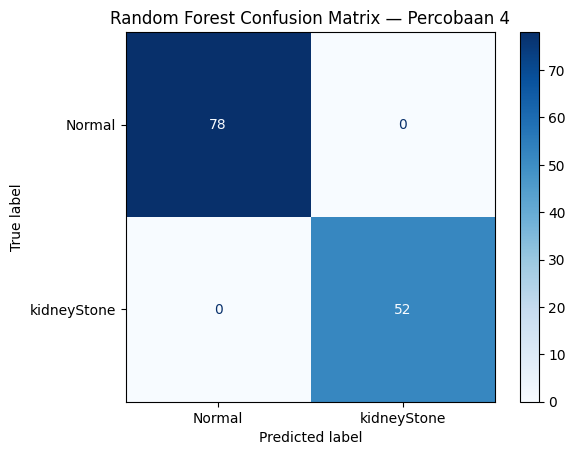

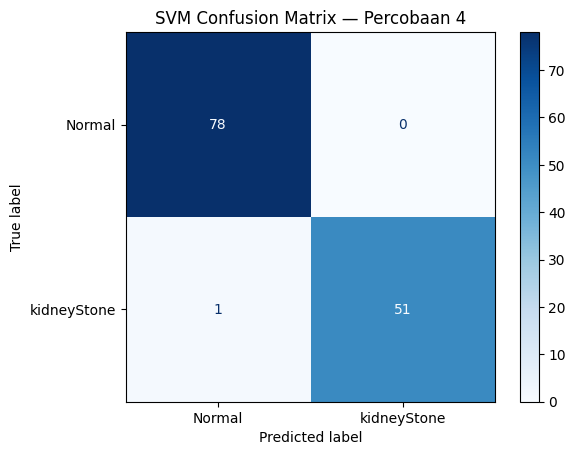

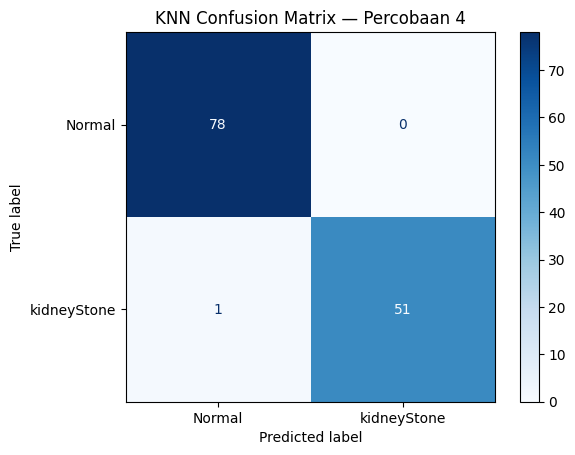

In [20]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 4')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 4')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 4')

## Ringkasan Hasil Percobaan 4

### Fungsi

Cell ini menampilkan ringkasan hasil eksperimen pada preprocessing keempat, meliputi metode preprocessing yang digunakan, jumlah fitur hasil seleksi, serta performa masing-masing algoritma klasifikasi pada data testing.

Ringkasan ini digunakan untuk mengevaluasi pengaruh kombinasi Median Filter, CLAHE, dan Thresholding terhadap kualitas fitur tekstur GLCM serta performa klasifikasi yang dihasilkan.

### Hasil Percobaan

**Metode Preprocessing:**
- Resize (256×256)
- Grayscale
- Median Filter
- CLAHE
- Thresholding

**Jumlah fitur setelah seleksi:**
- 10 fitur

**Akurasi Data Testing:**

| Algoritma | Accuracy |
|------------|------------|
| Random Forest | 100% |
| SVM | 99,23% |
| KNN | 99,23% |

### Analisis

Berdasarkan hasil pengujian, Random Forest memperoleh performa terbaik dengan nilai Accuracy sebesar 100%, sedangkan SVM dan KNN memperoleh Accuracy sebesar 99,23%.

Hasil tersebut menunjukkan bahwa kombinasi Median Filter, CLAHE, dan Thresholding mampu menghasilkan fitur tekstur yang sangat baik untuk proses klasifikasi citra ginjal. Namun, terdapat sedikit perbedaan performa antar algoritma pada preprocessing ini.

Median Filter membantu mengurangi noise pada citra, CLAHE meningkatkan kontras lokal sehingga detail tekstur menjadi lebih jelas, sedangkan Thresholding digunakan untuk memisahkan area objek dari latar belakang sehingga struktur utama ginjal menjadi lebih dominan.

Meskipun proses Thresholding mampu memperjelas area objek, proses tersebut juga berpotensi menghilangkan sebagian informasi intensitas dan tekstur halus yang terdapat pada citra asli. Hilangnya sebagian informasi tersebut dapat menyebabkan beberapa sampel memiliki karakteristik yang lebih sulit dibedakan.

Hal ini terlihat pada hasil SVM dan KNN yang masing-masing menghasilkan satu kesalahan klasifikasi pada data testing, sehingga nilai Accuracy menurun menjadi 99,23%. Sebaliknya, Random Forest tetap mampu mengklasifikasikan seluruh data dengan benar dan mempertahankan akurasi 100%.

Keunggulan Random Forest pada percobaan ini kemungkinan disebabkan oleh mekanisme ensemble learning yang menggunakan banyak pohon keputusan dan proses voting. Pendekatan tersebut membuat Random Forest lebih robust terhadap perubahan distribusi fitur yang dihasilkan oleh proses Thresholding.

Meskipun terdapat sedikit penurunan performa pada SVM dan KNN, seluruh algoritma tetap menunjukkan kemampuan klasifikasi yang sangat tinggi dengan nilai Accuracy di atas 99%. Hal ini menunjukkan bahwa fitur tekstur hasil ekstraksi GLCM masih mampu merepresentasikan karakteristik citra ginjal dengan baik setelah melalui proses preprocessing.

Secara keseluruhan, preprocessing keempat menghasilkan performa klasifikasi yang sangat baik. Random Forest menjadi algoritma terbaik pada percobaan ini karena mampu mempertahankan akurasi sempurna, sedangkan SVM dan KNN tetap menunjukkan performa yang sangat kompetitif dengan tingkat kesalahan yang sangat kecil.

In [21]:
print('=== RINGKASAN HASIL PERCOBAAN 4 ===')
print(f'Preprocessing: Resize (256x256) + Grayscale + Median + Clahe + Threshold')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 4 ===
Preprocessing: Resize (256x256) + Grayscale + Median + Clahe + Threshold
Jumlah Fitur Setelah Seleksi: 10

Akurasi Testing Set:
  Random Forest : 1.0000
  SVM           : 0.9923
  KNN           : 0.9923


# Perbandingan Keseluruhan Hasil Preprocessing dan Algoritma Klasifikasi

### Fungsi

Bagian ini digunakan untuk membandingkan seluruh skenario preprocessing yang diterapkan pada penelitian, serta mengevaluasi performa algoritma Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbor (KNN) berdasarkan hasil klasifikasi yang diperoleh.

Perbandingan dilakukan untuk mengetahui pengaruh masing-masing teknik preprocessing terhadap kualitas fitur tekstur GLCM dan performa model klasifikasi.

### Hasil Perbandingan

| Preprocessing | Jumlah Fitur | Random Forest | SVM | KNN |
|---------------|-------------|---------------|-----|-----|
| Resize + Grayscale | 10 | 100% | 100% | 100% |
| Resize + Grayscale + Median Filter + Histogram Equalization | 10 | 100% | 100% | 100% |
| Resize + Grayscale + CLAHE + Sharpening | 6 | 99,62% | 100% | 100% |
| Resize + Grayscale + Median Filter + CLAHE + Thresholding | 10 | 100% | 99,23% | 99,23% |

### Analisis

Berdasarkan hasil pengujian, seluruh skenario preprocessing menghasilkan performa klasifikasi yang sangat tinggi dengan nilai Accuracy di atas 99%.

Pada preprocessing pertama, kombinasi Resize dan Grayscale telah mampu menghasilkan fitur tekstur yang cukup representatif sehingga seluruh algoritma berhasil mencapai Accuracy sebesar 100%. Hasil ini menunjukkan bahwa perbedaan karakteristik tekstur antara citra ginjal Normal dan Kidney Stone sudah dapat ditangkap dengan baik oleh fitur GLCM tanpa memerlukan proses peningkatan kualitas citra tambahan.

Pada preprocessing kedua, penambahan Median Filter dan Histogram Equalization tidak meningkatkan nilai Accuracy karena seluruh algoritma tetap memperoleh nilai 100%. Namun demikian, kedua teknik tersebut membantu mengurangi noise dan meningkatkan kontras citra sehingga kualitas tekstur yang diekstraksi menjadi lebih baik dan lebih stabil.

Preprocessing ketiga menunjukkan hasil yang menarik karena setelah proses seleksi fitur hanya tersisa 6 fitur dari total 28 fitur awal. Meskipun jumlah fitur berkurang secara signifikan, SVM dan KNN tetap mampu mencapai Accuracy sebesar 100%, sedangkan Random Forest memperoleh Accuracy sebesar 99,62%. Hasil ini menunjukkan bahwa kombinasi CLAHE dan Sharpening mampu menghasilkan fitur yang lebih efisien tanpa menurunkan performa klasifikasi secara signifikan.

Pada preprocessing keempat, penggunaan Thresholding menghasilkan performa yang sedikit berbeda. Random Forest tetap mampu mempertahankan Accuracy sebesar 100%, sedangkan SVM dan KNN mengalami sedikit penurunan performa menjadi 99,23%. Penurunan ini kemungkinan disebabkan oleh hilangnya sebagian informasi tekstur halus akibat proses Thresholding yang mengubah citra menjadi representasi yang lebih sederhana.

Jika ditinjau dari sisi performa klasifikasi, preprocessing pertama dan kedua menghasilkan performa terbaik karena seluruh algoritma berhasil mencapai Accuracy sebesar 100%. Namun apabila mempertimbangkan efisiensi fitur, preprocessing ketiga menjadi alternatif yang menarik karena hanya membutuhkan 6 fitur untuk menghasilkan performa yang hampir identik dengan preprocessing lainnya.

Dari sisi algoritma, Random Forest menunjukkan performa yang paling stabil karena mampu mencapai Accuracy 100% pada tiga dari empat skenario preprocessing. Sementara itu, SVM dan KNN menunjukkan performa yang sangat baik pada sebagian besar skenario, namun sedikit terpengaruh oleh proses Thresholding pada preprocessing keempat.

### Kesimpulan

Berdasarkan seluruh hasil pengujian, fitur tekstur GLCM terbukti sangat efektif dalam membedakan citra ginjal Normal dan Kidney Stone pada seluruh skenario preprocessing yang digunakan.

Preprocessing ketiga (CLAHE + Sharpening) menghasilkan representasi fitur yang paling efisien karena hanya menggunakan 6 fitur setelah seleksi dengan performa klasifikasi yang tetap sangat tinggi. Sementara itu, Random Forest merupakan algoritma yang paling stabil terhadap variasi preprocessing karena mampu mempertahankan performa terbaik pada hampir seluruh skenario pengujian.

Secara keseluruhan, kombinasi preprocessing, ekstraksi fitur GLCM, seleksi fitur berbasis Correlation Matrix, dan algoritma klasifikasi yang digunakan berhasil menghasilkan sistem klasifikasi citra ginjal dengan tingkat akurasi yang sangat tinggi.